# _AutoTS Apple Stock Price Prediction_

<img src='../data/img.webp'>

In [1]:
import pandas as pd  
# Veri manipülasyonu ve analiz için pandas kütüphanesini yüklüyoruz

import numpy as np  
# Sayısal işlemler ve diziler için NumPy kütüphanesini yüklüyoruz

import matplotlib.pyplot as plt  
# Statik grafikler çizmek için Matplotlib kütüphanesini yüklüyoruz

import seaborn as sns  
# Gelişmiş ve istatistiksel görselleştirmeler için Seaborn kütüphanesini yüklüyoruz

import plotly.express as px  
# İnteraktif grafikler ve görselleştirmeler için Plotly Express kütüphanesini yüklüyoruz

In [2]:
import warnings
warnings.filterwarnings("ignore")  # Tüm uyarıları gizle

In [18]:
#pip install autots

In [19]:
from autots import AutoTS

In [3]:
#pip install prophet

In [4]:
df = pd.read_csv('../data/AAPL.csv')

# CSV dosyasını pandas DataFrame olarak okuyoruz

In [5]:
df.head()

# DataFrame'in ilk 5 satırını görüntüleyerek veri yapısını hızlıca inceliyoruz

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600


In [6]:
df = df[['Date', 'Close']]

In [8]:
df.info()

# DataFrame'in sütunları, veri tipleri ve boş değer sayıları hakkında özet bilgi alıyoruz

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    184 non-null    object 
 1   Close   184 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.0+ KB


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
# 'date' sütununu datetime formatına çeviriyoruz, böylece zaman serisi analizleri yapabiliriz

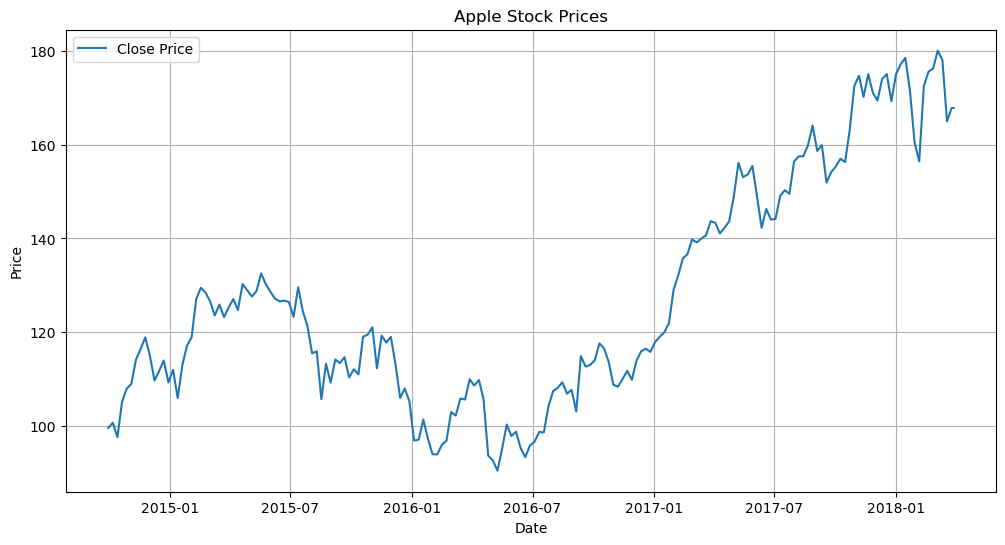

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.title("Apple Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
df.info()

# DataFrame'in güncellenmiş sütun tiplerini ve eksik değer bilgilerini kontrol ediyoruz

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    184 non-null    datetime64[ns]
 1   Close   184 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.0 KB


In [11]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month

# 'date' sütunundan yıl ve ay bilgilerini çıkararak yeni sütunlar oluşturuyoruz

In [12]:
df.head()

,Date,Close,year,month
0,2014-09-29,99.620003,2014,9
1,2014-10-06,100.730003,2014,10
2,2014-10-13,97.669998,2014,10
3,2014-10-20,105.220001,2014,10
4,2014-10-27,108.000000,2014,10


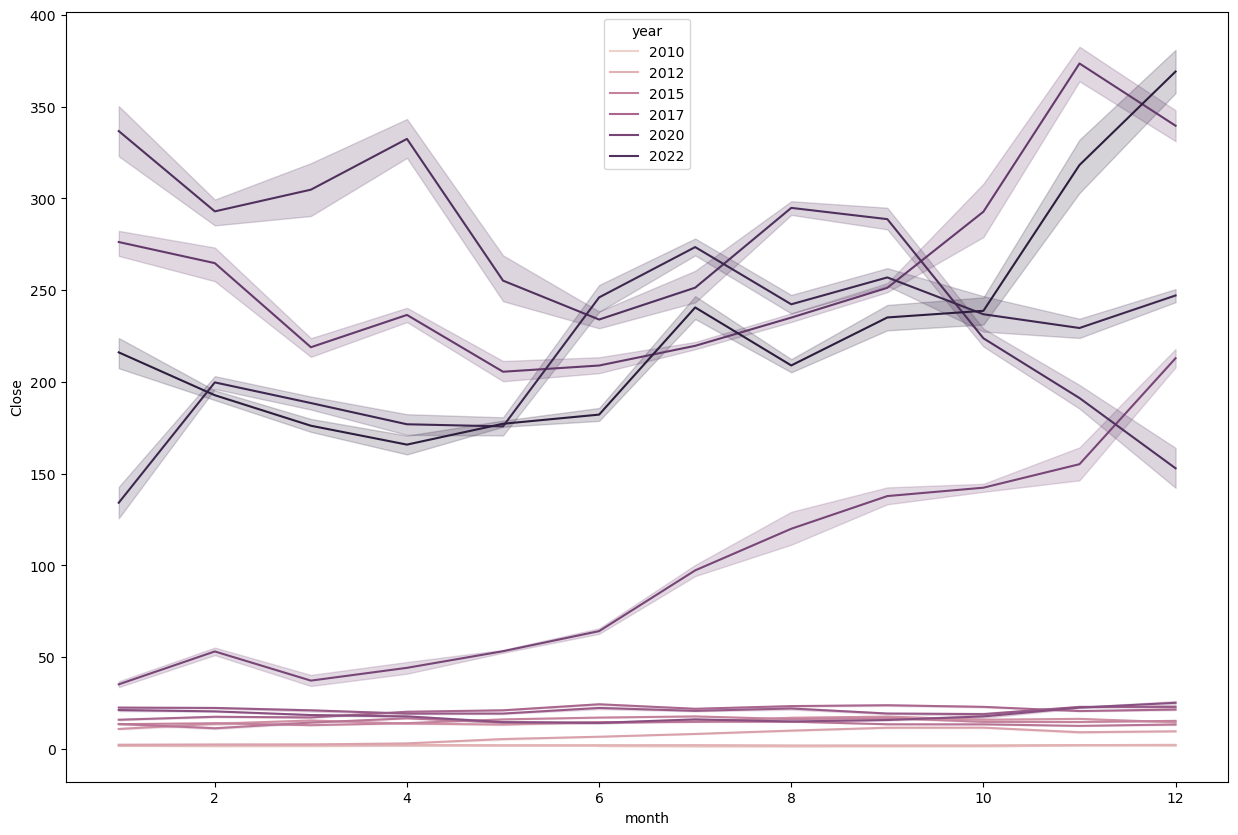

In [13]:
plt.figure(figsize=(15, 10))
sns.lineplot(df, x='month', y='Close', hue='year');

In [20]:
# Modeli oluştur
model = AutoTS(
    forecast_length=10,     # 10 günlük tahmin
    frequency='infer',      # Otomatik frekans tespiti
    ensemble='simple',      # Basit ensemble
)

Using 4 cpus for n_jobs.


In [22]:
# Modeli eğit
model = model.fit(
    df,
    date_col='Date',
    value_col='Close'
)

Data frequency is: W-MON, used frequency is: W-MON
Model Number: 1 with model AverageValueNaive in generation 0 of 25
Model Number: 2 with model AverageValueNaive in generation 0 of 25
Model Number: 3 with model AverageValueNaive in generation 0 of 25
Model Number: 4 with model DatepartRegression in generation 0 of 25
Model Number: 5 with model ETS in generation 0 of 25
Model Number: 6 with model GLM in generation 0 of 25
Model Number: 7 with model GLS in generation 0 of 25
Model Number: 8 with model LastValueNaive in generation 0 of 25
Model Number: 9 with model LastValueNaive in generation 0 of 25
Model Number: 10 with model LastValueNaive in generation 0 of 25
Model Number: 11 with model SeasonalNaive in generation 0 of 25
Model Number: 12 with model SeasonalNaive in generation 0 of 25
Model Number: 13 with model VAR in generation 0 of 25
Template Eval Error: ValueError('Only gave one variable to VAR') in model 13 in generation 0: VAR
Model Number: 14 with model ConstantNaive in gen

C:\Users\13tua\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning:

The InversePower link function does not respect the domain of the Gamma family.



Model Number: 84 with model ETS in generation 0 of 25
Model Number: 85 with model ARDL in generation 0 of 25
Model Number: 86 with model SectionalMotif in generation 0 of 25
Model Number: 87 with model UnivariateMotif in generation 0 of 25
Model Number: 88 with model BasicLinearModel in generation 0 of 25
Model Number: 89 with model SeasonalNaive in generation 0 of 25
Model Number: 90 with model AverageValueNaive in generation 0 of 25
Model Number: 91 with model SeasonalityMotif in generation 0 of 25
Model Number: 92 with model DatepartRegression in generation 0 of 25
Model Number: 93 with model FFT in generation 0 of 25
Model Number: 94 with model SeasonalNaive in generation 0 of 25
Model Number: 95 with model UnivariateMotif in generation 0 of 25
Model Number: 96 with model FFT in generation 0 of 25
Model Number: 97 with model GLS in generation 0 of 25
Model Number: 98 with model SectionalMotif in generation 0 of 25
Model Number: 99 with model DatepartRegression in generation 0 of 25

C:\Users\13tua\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning:

The InversePower link function does not respect the domain of the Gamma family.



Model Number: 440 with model LastValueNaive in generation 3 of 25
Model Number: 441 with model BasicLinearModel in generation 3 of 25
Template Eval Error: Exception("Transformer ChangepointDetector failed on fit from params ffill {'0': {'method': 'none', 'method_params': {}, 'aggregate_method': 'mean'}, '1': {'model': 'Linear', 'phi': 1, 'window': None, 'transform_dict': {'fillna': None, 'transformations': {'0': 'bkfilter'}, 'transformation_params': {'0': {}}}}, '2': {}} with error ValueError('Must call detect() or fit() before generating trends.')") in model 441 in generation 3: BasicLinearModel
Model Number: 442 with model WindowRegression in generation 3 of 25
Model Number: 443 with model DatepartRegression in generation 3 of 25
Template Eval Error: Exception("Transformer ChangepointDetector failed on fit from params rolling_mean_24 {'0': {'regression_model': {'model': 'RandomForest', 'model_params': {'n_estimators': 100, 'min_samples_leaf': 1, 'bootstrap': True}}, 'datepart_method'

...

Model Number: 369 of 303 with model GLS for Validation 2
369 - GLS with avg smape 32.93 in 0.05s: 
Model Number: 370 of 303 with model GLM for Validation 2
370 - GLM with avg smape 33.09 in 0.03s: 
Model Number: 371 of 303 with model GLS for Validation 2
371 - GLS with avg smape 33.23 in 0.03s: 
Model Number: 372 of 303 with model GLS for Validation 2
372 - GLS with avg smape 31.39 in 0.03s: 
Model Number: 373 of 303 with model GLS for Validation 2
373 - GLS with avg smape 31.39 in 0.02s: 
Model Number: 374 of 303 with model GLS for Validation 2
374 - GLS with avg smape 31.39 in 0.02s: 
Model Number: 375 of 303 with model GLS for Validation 2
375 - GLS with avg smape 33.57 in 0.03s: 
Model Number: 376 of 303 with model WindowRegression for Validation 2
376 - WindowRegression with avg smape 27.42 in 0.24s: 
Model Number: 377 of 303 with model GLM for Validation 2
377 - GLM with avg smape 33.92 in 0.02s: 
Model Number: 378 of 303 with model GLM for Validation 2
378 - GLM with avg smape 2

C:\Users\13tua\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning:

Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.



359 - WindowRegression with avg smape 5.89 in 0.22s: 
Model Number: 360 of 303 with model GLM for Validation 3
360 - GLM with avg smape 12.13 in 0.03s: 
Model Number: 361 of 303 with model WindowRegression for Validation 3
361 - WindowRegression with avg smape 19.48 in 0.02s: 
Model Number: 362 of 303 with model WindowRegression for Validation 3
362 - WindowRegression with avg smape 11.16 in 0.07s: 
Model Number: 363 of 303 with model ConstantNaive for Validation 3
363 - ConstantNaive with avg smape 16.24 in 0.02s: 
Model Number: 364 of 303 with model GLM for Validation 3
364 - GLM with avg smape 5.16 in 0.04s: 
Model Number: 365 of 303 with model GLM for Validation 3
365 - GLM with avg smape 27.74 in 0.04s: 
Model Number: 366 of 303 with model GLS for Validation 3
366 - GLS with avg smape 24.8 in 0.03s: 
Model Number: 367 of 303 with model GLS for Validation 3
367 - GLS with avg smape 26.89 in 0.05s: 
Model Number: 368 of 303 with model GLS for Validation 3


C:\Users\13tua\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning:

The InversePower link function does not respect the domain of the Gamma family.



368 - GLS with avg smape 27.36 in 0.04s: 
Model Number: 369 of 303 with model GLS for Validation 3
369 - GLS with avg smape 29.92 in 0.03s: 
Model Number: 370 of 303 with model GLM for Validation 3
370 - GLM with avg smape 29.92 in 0.02s: 
Model Number: 371 of 303 with model GLS for Validation 3
371 - GLS with avg smape 29.93 in 0.04s: 
Model Number: 372 of 303 with model GLS for Validation 3
372 - GLS with avg smape 27.83 in 0.03s: 
Model Number: 373 of 303 with model GLS for Validation 3
373 - GLS with avg smape 27.83 in 0.03s: 
Model Number: 374 of 303 with model GLS for Validation 3
374 - GLS with avg smape 27.83 in 0.03s: 
Model Number: 375 of 303 with model GLS for Validation 3
375 - GLS with avg smape 30.17 in 0.03s: 
Model Number: 376 of 303 with model WindowRegression for Validation 3
376 - WindowRegression with avg smape 25.87 in 0.27s: 
Model Number: 377 of 303 with model GLM for Validation 3
377 - GLM with avg smape 30.4 in 0.03s: 
Model Number: 378 of 303 with model GLM fo

In [23]:
prediction = model.predict()

In [24]:
forecast = prediction.forecast

In [25]:
print("Apple Stock Price Prediction (Next 10 Days):")
print(forecast)

Apple Stock Price Prediction (Next 10 Days):
                 Close
2018-04-09  167.779999
2018-04-16  167.706677
2018-04-23  168.485622
2018-04-30  169.036123
2018-05-07  169.533240
2018-05-14  169.191363
2018-05-21  169.673757
2018-05-28  168.999676
2018-06-04  169.869661
2018-06-11  170.357659


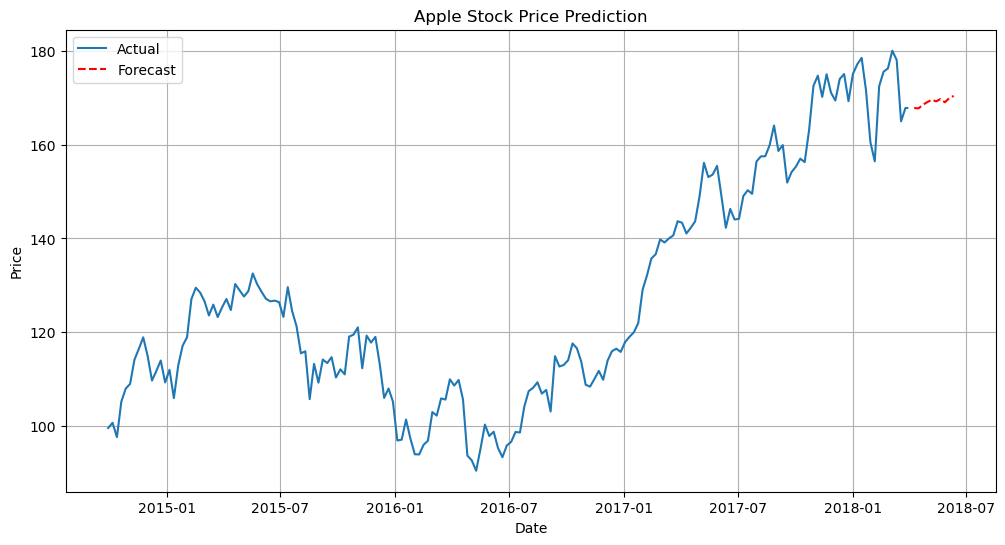

In [27]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Actual')
plt.plot(forecast.index, forecast['Close'], label='Forecast', linestyle='--', color='red')
plt.title("Apple Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
import joblib  # Modeli kaydetmek için

In [29]:
# Modeli kaydet
joblib.dump(model, "autots_model.pkl")

['autots_model.pkl']